<h1>Evolución temporal</h1>
 La evolución del estado cuántico $\psi$ esta representada de la siguiente manera: 

\begin{equation}
|\psi(t)\rangle = e^{-i H t} |\psi(0)\rangle.
\end{equation}

Sustituyendo el hamiltoniano obtenido anteriormente en esta ecuación

\begin{equation}
U = e^{-i t (-J \sum_{i=1}^{N-1} Z_i Z_{i+1} - h \sum_{i=1}^{N} X_i)} = e^{i t J \sum_{i=1}^{N-1} Z_i Z_{i+1}} e^{i t h \sum_{i=1}^{N} X_i} 
\end{equation}

Troterizando este operador , obtenemos el trotter de primer grado 

\begin{equation}
U \approx \left( \prod_{i=1}^{N-1} e^{i J \Delta t Z_i Z_{i+1}} \prod_{i=1}^{N} e^{i h \Delta t X_i} \right)^{n},
\end{equation}

Donde $\Delta t = t/n$ y n es el número de pasos

Una vez obtenida la troterización el siguiente paso es representar esta evolución con gates en nuestro circuito cuántico, para ello 

\begin{equation}
e^{i \theta Z_i \otimes Z_{i+1}} = R_{ZZ}(2*\theta)
\end{equation}

En guppy esta transformacion se puede simular con un gate cx, rz, cx  con $\theta = J \Delta t$. 

\begin{equation}
e^{i \theta_2 X_i} = R_{X}(2*\theta_2)
\end{equation}

donde $\theta_2 = h \Delta t$ y corresponde a la Rx 


Suzuki Trotter 

\begin{equation}
U \approx \left( \prod_{i=1}^{N} e^{i h \Delta t/2 X_i}  \prod_{i=1}^{N-1} e^{i J \Delta t Z_i Z_{i+1}} \prod_{i=1}^{N} e^{i h \Delta t/2 X_i} \right)^{n},
\end{equation}

In [15]:
import math
import numpy as np
from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import qubit, h, cx, rx, rz, measure_array
from guppylang.std.angles import angle, pi
from guppylang.std.builtins import comptime
from guppylang.defs import GuppyFunctionDefinition
from hugr.qsystem.result import QsysResult

from selene_sim import build, Quest
import qnexus as qnx
from datetime import datetime

N = 6                 # number of qubits -- keep small
J = 1.0
H_FIELD_OVER_J = 0.5   # h/J for the quench Hamiltonian
H_FIELD = H_FIELD_OVER_J * J

T_MAX = 15.0
N_STEPS = 150          # number of Trotter steps taken to reach T_MAX
DT = T_MAX / N_STEPS   # Trotter step size
N_SHOTS = 2000

@guppy.comptime
def simple_trotter_step(qs: array[qubit, comptime(N)], dt: float) -> None:
    # Trotter simple RZZ , RX 

    #theta_zz = angle(-2.0 * comptime(J) * dt / pi)
    theta_zz = -2.0 * comptime(J) * dt / pi
    for i in range(N - 1):
        # ZZ rotation implemented as CX - RZ - CX
        cx(qs[i], qs[i + 1])
        rz(qs[i + 1], theta_zz)
        cx(qs[i], qs[i + 1])
    # periodic bond (site N-1 <-> site 0); 
    cx(qs[N - 1], qs[0])
    rz(qs[0], theta_zz)
    cx(qs[N - 1], qs[0])

    # X field term: exp(+i h dt X_i)  =>  rx(theta) with theta = -2 h dt (radians)
    theta_x = angle(-2.0 * H_FIELD * dt / math.pi)
    for i in range(N):
        rx(qs[i], theta_x)


@guppy.comptime
def suzuki_trotter_step(qs: array[qubit, comptime(N)], dt: float) -> None:
    #For the suski trotter_step we add a X rotation at beginning with half th eangle 

    theta_x = angle(-1.0 * H_FIELD * dt / math.pi)
    for i in range(N):
        rx(qs[i], theta_x)

    
    theta_zz = angle(-2.0 * J * dt / math.pi)
    for i in range(N - 1):
        # ZZ rotation implemented as CX - RZ - CX
        cx(qs[i], qs[i + 1])
        rz(qs[i + 1], theta_zz)
        cx(qs[i], qs[i + 1])
    # periodic bond (site N-1 <-> site 0); 
    cx(qs[N - 1], qs[0])
    rz(qs[0], theta_zz)
    cx(qs[N - 1], qs[0])

    # X field term: exp(+i h dt X_i)  =>  rx(theta) with theta = -2 h dt (radians)
    theta_x = angle(-1.0 * H_FIELD * dt / math.pi)
    for i in range(N):
        rx(qs[i], theta_x)


# ------------------------------------------------------------------
# Full circuit: evolve to time t = n_steps * dt, then measure in a
# chosen basis. basis_x=True rotates every qubit to the X basis
# (apply H) right before measurement.
# ------------------------------------------------------------------

def make_circuit(n_steps: int, basis_x: bool) -> GuppyFunctionDefinition:
    
    @guppy.comptime
    def circuit() -> None:
        qs = array(qubit() for _ in range(comptime(N)))
        for _ in range(comptime(n_steps)):
            suzuki_trotter_step(qs, comptime(DT))
        if comptime(basis_x):
            for i in range(comptime(N)):
                h(qs[i])
        bits = measure_array(qs)
        result("bits", bits)

    return circuit


# ------------------------------------------------------------------
# Run one circuit on Selene, return the raw bitstrings (list[list[int]])
# ------------------------------------------------------------------
def run_circuit(n_steps: int, basis_x: bool, shots: int = N_SHOTS):
    circuit = make_circuit(n_steps, basis_x)
    compiled = circuit.compile_function()
    runner = build(compiled) # Funcion de selene para simular 
    sim_result = QsysResult(runner.run_shots(simulator=Quest(), n_qubits=N, n_shots=shots)) #utilizamos QsysResult para parsear los shots obtenidos 
    all_bits = [shot.as_dict()["bits"] for shot in sim_result]
    # each shot's "bits" register -> list of 0/1 outcomes, length N
    return np.array(all_bits)  # shape (shots, N), values in {0, 1}


# ------------------------------------------------------------------
# Convert measured bitstrings into expectation values
# ------------------------------------------------------------------
def z_expectation_from_bits(bits):
    """bits: (shots, N) array of 0/1. Returns mean <Z> over qubits and shots."""
    spins = 1 - 2 * bits  # 0 -> +1, 1 -> -1
    return spins.mean()

def zz_expectation_from_bits(bits, nn_only=True):
    spins = 1 - 2 * bits  # (shots, N)
    shots, n = spins.shape
    total, count = 0.0, 0
    pairs = [(i, (i + 1) % n) for i in range(n)] if nn_only else \
            [(i, j) for i in range(n) for j in range(i + 1, n)]
    for i, j in pairs:
        total += (spins[:, i] * spins[:, j]).mean()
        count += 1
    return total / count


def mean_z_overall(counts):
    """Average <Z> across all qubits and all shots."""
    total_shots = sum(counts.values())
    n_qubits = len(next(iter(counts))[0][1])
    acc = 0
    for key, n in counts.items():
        bitstring = key[0][1]
        for bit in bitstring:
            z = 1 if bit == '0' else -1
            acc += z * n
    return acc / (total_shots * n_qubits)

def mean_zi_zi1_correlator(counts):
    """Promedio de <Zi*Zi+1> sobre todos los pares de qubits adyacentes y todos los shots."""
    total_shots = sum(counts.values())
    n_qubits = len(next(iter(counts))[0][1])
    n_pairs = n_qubits - 1
    acc = 0
    for key, n in counts.items():
        bitstring = key[0][1]
        for i in range(n_pairs):
            zi = 1 if bitstring[i] == '0' else -1
            zi1 = 1 if bitstring[i + 1] == '0' else -1
            acc += (zi * zi1) * n
    return acc / (total_shots * n_pairs)

# ------------------------------------------------------------------
# Evolucion temporal del sistema
# ------------------------------------------------------------------
def quantum_dynamics_scan(step_counts):
    times, Z_vals, X_vals, ZZ_nn_vals = [], [], [], []
    for n_steps in step_counts:
        t = n_steps * DT
        bits_z = run_circuit(n_steps, basis_x=False)
        bits_x = run_circuit(n_steps, basis_x=True)

        times.append(t)
        Z_vals.append(z_expectation_from_bits(bits_z))
        X_vals.append(z_expectation_from_bits(bits_x))   # measured in X basis -> gives <X>
        ZZ_nn_vals.append(zz_expectation_from_bits(bits_z, nn_only=True))

    return {
        "t": np.array(times),
        "Z": np.array(Z_vals),
        "X": np.array(X_vals),
        "ZZ_nn": np.array(ZZ_nn_vals),
    }

def quantum_dynamics_scan2(step_counts):
    times, Z_vals, ZZ_vals = [], [], []
    for n_steps in step_counts:
        t = n_steps * DT
        counts = run_circuit_selene(n_steps, basis_x=False)

        times.append(t)
        Z_vals.append(mean_z_overall(counts))
        ZZ_vals.append(mean_zi_zi1_correlator(counts))

    return {
        "t": np.array(times),
        "Z": np.array(Z_vals),
        "ZZ_nn": np.array(ZZ_vals)
    }
    
def exact_classical_reference(times):
    """
    Implementacion de evolucion clasica del sitema con ED
    """
    from scipy.sparse import kron, identity, csr_matrix
    from scipy.sparse.linalg import expm_multiply

    X_op = csr_matrix([[0, 1], [1, 0]])
    Z_op = csr_matrix([[1, 0], [0, -1]])
    I_op = identity(2, format='csr')

    def op_on_site(op, site, n):
        ops = [I_op] * n
        ops[site] = op
        out = ops[0]
        for o in ops[1:]:
            out = kron(out, o, format='csr')
        return out

    def build_H(n, J_, h_, pbc=True):
        Hm = csr_matrix((2**n, 2**n))
        bonds = n if pbc else n - 1
        for i in range(bonds):
            j = (i + 1) % n
            Hm -= J_ * (op_on_site(Z_op, i, n) @ op_on_site(Z_op, j, n)) 
        for i in range(n):
            Hm -= h_ * op_on_site(X_op, i, n) # Como estamos analizando evolucion temporal , no necesitamos agregar la rotación Rz para romper Z2 symetry 
        return Hm

    def expval(psi, op):
        return (psi.conj() @ (op @ psi)).real

    Hm = build_H(N, J, H_FIELD, pbc=True)
    psi0 = np.zeros(2**N, dtype=complex)
    psi0[0] = 1.0  # |000...0>

    dt_list = np.diff(times)
    psi = psi0.copy()
    Zs, Xs, ZZ_nns = [], [], []

    def record(psi):
        Zs.append(sum(expval(psi, op_on_site(Z_op, i, N)) for i in range(N)) / N)
        Xs.append(sum(expval(psi, op_on_site(X_op, i, N)) for i in range(N)) / N)
        bonds = N # Condiciones de frontera periodica 
        zz = 0.0
        for i in range(N):
            j = (i + 1) % N
            zz += expval(psi, op_on_site(Z_op, i, N) @ op_on_site(Z_op, j, N))
        ZZ_nns.append(zz / bonds)

    record(psi) # Record del estado incial
    for dt in dt_list:
        psi = expm_multiply(-1j * Hm * dt, psi) # utlizamos la funcion expm_multiply en vez de 
        """
        # Evolución: |ψ(t)> = sum_k e^{-i E_k t} |k><k|ψ(0)>
        for k in range(dim):
            coeff = np.exp(-1j * eigenvalues[k] * t)
            coeff *= np.vdot(eigenvectors[:, k], psi0)
            psi_t += coeff * eigenvectors[:, k]
        """
        psi /= np.linalg.norm(psi) # Normalizar 
        record(psi)

    return {"t": np.array(times), "Z": np.array(Zs), "X": np.array(Xs), "ZZ_nn": np.array(ZZ_nns)}





In [16]:
def get_results_selene_lcl_sim():
    # Cada 10 pasos de trotter hacemos una corrida en selene
    # Cada vez que llamamos la funcion make_circuit, llamamos a selene 
    step_counts = list(range(0, N_STEPS + 1, 30))
    quantum_data = quantum_dynamics_scan(step_counts)

    for t, z, x, zz in zip(quantum_data["t"], quantum_data["Z"],
                            quantum_data["X"], quantum_data["ZZ_nn"]):
        print(f"t={t:6.2f}  <Z>={z:+.4f}  <X>={x:+.4f}  <ZiZj>_nn={zz:+.4f}")

    # --- Exact classical reference, evaluated at the same times ---
    classical_data = exact_classical_reference(quantum_data["t"])

    # --- Comparison plot ---
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharex=True)
    labels = [("Z", r"$\langle Z \rangle$"),
              ("ZZ_nn", r"$\langle Z_i Z_{i+1} \rangle$")]

    for ax, (key, ylabel) in zip(axes, labels):
        ax.plot(classical_data["t"], classical_data[key], '-', color='black',
                label="Exact (classical ED)", linewidth=2)
        ax.plot(quantum_data["t"], quantum_data[key], 'o', color='crimson',
                label=f"Trotter circuit ({N_SHOTS} shots)", markersize=5)
        ax.set_xlabel("Time (1/J)")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    fig.suptitle(f"TFIM quench: quantum circuit (Suzuki Trotter, Selene) vs exact classical, "
                 f"N={N}, h/J={H_FIELD_OVER_J}, dt={DT:.3f}")
    fig.tight_layout()
    fig.savefig("SuzukiTrotter_with_SNS_tfim_quantum_vs_classical.png", dpi=150)
    print("\nComparison plot saved.")

In [17]:
def get_results_selene_nexus():
    # Cada 10 pasos de trotter hacemos una corrida en selene
    # Cada vez que llamamos la funcion make_circuit, llamamos a selene 
    step_counts = list(range(0, N_STEPS + 1, 30))
    quantum_data = quantum_dynamics_scan2(step_counts)

    for t, z, zz in zip(quantum_data["t"], quantum_data["Z"], quantum_data["ZZ_nn"]):
        print(f"t={t:6.2f}  <Z>={z:+.4f} <ZZ>={zz:+.4f}")

    # --- Exact classical reference, evaluated at the same times ---
    classical_data = exact_classical_reference(quantum_data["t"])

    # --- Comparison plot ---
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharex=True)
    labels = [("Z", r"$\langle Z \rangle$"), ("ZZ_nn", r"$\langle Z_i Z_{i+1} \rangle$")]

    for ax, (key, ylabel) in zip(axes, labels):
        ax.plot(classical_data["t"], classical_data[key], '-', color='black',
                label="Exact (classical ED)", linewidth=2)
        ax.plot(quantum_data["t"], quantum_data[key], 'o', color='crimson',
                label=f"Trotter circuit ({N_SHOTS} shots)", markersize=5)
        ax.set_xlabel("Time (1/J)")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    fig.suptitle(f"TFIM quench: quantum circuit (Suzuki Trotter, Selene) vs exact classical, "
                 f"N={N}, h/J={H_FIELD_OVER_J}, dt={DT:.3f}")
    fig.tight_layout()
    fig.savefig("SuzukiTrotter_with_SLS_tfim_quantum_vs_classical.png", dpi=150)
    print("\nComparison plot saved.")

In [12]:

qnx.login()
project = qnx.projects.get_or_create("TFIM-Trotter-Selene")
qnx.context.set_active_project(project)

def run_circuit_selene(n_steps, basis_x):
    

#def make_circuit(n_steps: int, basis_x: bool, shots: int = N_SHOTS):
    circuit = make_circuit(n_steps, False)
    HUGR = circuit.compile()

    hugr_ref = qnx.hugr.upload(
        hugr_package=HUGR,
        name="Trotter 6 Qubit",
    )

    config = qnx.models.SeleneConfig(
        n_qubits=6, 
        simulator=qnx.models.StatevectorSimulator()
    )

    selene_quest_job_ref = qnx.start_execute_job(
        programs=[hugr_ref],
        n_shots=[2000],
        backend_config=config,
        name=f"Suzuki trotter Selene {datetime.now()}",
    )

    # Might take time during busy periods
    qnx.jobs.wait_for(selene_quest_job_ref, timeout=None)
    
    qsys_result = qnx.jobs.results(selene_quest_job_ref)[0].download_result()
    
    return qsys_result.collated_counts()





🌐 Browser log in initiated.


╭────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                        │
│         Confirm that the browser shows the following code and click 'allow device':    │
│                                                                                        │
│                                      vMWZCE                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Browser didn't open automatically? Use this link: https://nexus.quantinuum.com/auth/device/browser?otp=vMWZCEw11DPUrsSgcbat5LC0F6u8uDic3HrtT9j0fkcSK_7xtQUzuRtu73Frif0MWiZyAb6N83yeIo1d-Rx4UQ
✅ Successfully logged in as fercorado01@gmail.com using the browser.


In [13]:
get_results_selene_nexus()

Task was destroyed but it is pending!
task: <Task pending name='Task-147' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/wicho3000/.pyenv/versions/3.14.3/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-148' coro=<Kernel.shell_main() running at /home/wicho3000/.pyenv/versions/3.14.3/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/wicho3000/.pyenv/versions/3.14.3/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/wicho3000/.pyenv/versions/3.14.3/lib/python3.14/copy.py:110: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def deepcopy(x, memo=None, _nil=[]):
Task was destroyed but it is pending!
task: <Task pending name='Task-148' coro=<Kernel.shell_main() running at /home/wicho3000/.pyenv/versions/3.14.3/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Exception in 

KeyboardInterrupt: 

t=  0.00  <Z>=+1.0000  <X>=+0.0018  <ZiZj>_nn=+1.0000
t=  3.00  <Z>=+0.8343  <X>=+0.2647  <ZiZj>_nn=+0.8687
t=  6.00  <Z>=+0.8867  <X>=+0.3108  <ZiZj>_nn=+0.8450
t=  9.00  <Z>=+0.8272  <X>=+0.3042  <ZiZj>_nn=+0.8427
t= 12.00  <Z>=+0.8565  <X>=+0.3592  <ZiZj>_nn=+0.8247
t= 15.00  <Z>=+0.8572  <X>=+0.2512  <ZiZj>_nn=+0.8747

Comparison plot saved.


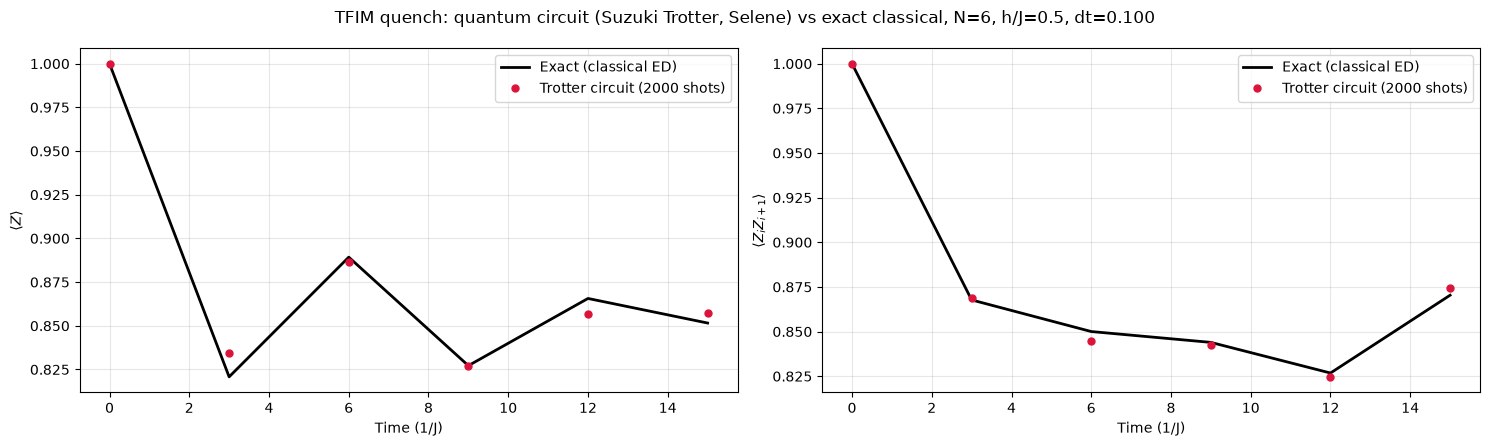

In [18]:
get_results_selene_lcl_sim()